# EDA : Pill Detection 
### Data สามารถโหลดได้จาก
**Dataset:** `https://www.kaggle.com/datasets/alexanderyyy/pills-detection-dataset`  

### import & path

In [37]:
import hashlib
import math
import random
from collections import Counter
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image, ImageOps


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()

DATASET_ROOT = PROJECT_ROOT / "pill-dataset"

IMAGE_ROOT = DATASET_ROOT / "images"

LABEL_ROOT = DATASET_ROOT / "labels"

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

SPLITS = ["train", "val"]

print("Dataset:", DATASET_ROOT)


Dataset: c:\Project\pill-object-detection\pill-dataset


### จำนวน Image & Labels

In [ ]:
rows = []

for split in SPLITS:
    image_dir = IMAGE_ROOT / split
    label_dir = LABEL_ROOT / split

    # ค้นหารูป ที่นามสกุลตรง IMAGE_EXTs
    images = [p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]

    labels = list(label_dir.glob("*.txt"))

    # ดึงเฉพาะชื่อไฟล์ ไม่เอา นามสกุลไฟล์
    image_steams = {p.stem.lower() for p in images}

    label_stems = {p.stem.lower() for p in labels}

    rows.append(
        {
            "split": split,
            "images": len(images),
            "labels": len(labels),
            "missimg_labels": len(image_steams - label_stems),  # จำนวนภาพไม่มี label
            "orphan_labels": len(label_stems - image_steams),  # จำนวนไฟล์ label ไม่มีคู่
        }
    )

# แปลง rows ให้เป็น DataFrame
pairing_df = pd.DataFrame(rows)
display(pairing_df)


,split,images,labels,missimg_labels,orphan_labels
0,train,10559,10559,0,0
1,val,1508,1508,0,0


### ดู Image Metadata

In [ ]:
image_rows = []
corrupt_images = []

for split in SPLITS:
    image_dir = IMAGE_ROOT / split
    label_dir = LABEL_ROOT / split

    # วน loop อ่านทีละไฟล์ใน Folder รูป
    for image_path in image_dir.iterdir():
        if image_path.suffix.lower() not in IMAGE_EXTS:
            continue

        # สร้าง path หาไฟล์ ชื่อเดียวกับรูป
        label_path = label_dir / f"{image_path.stem}.txt"

        try:
            with Image.open(image_path) as im:
                width, height = im.size
                # ตรวจสอบความสมบูรณ์ ไม่มีความเสียหาย
                im.verify()

            image_rows.append(
                {
                    "split": split,
                    "stem": image_path.stem,  # ชื่อไฟล์
                    "image_path": image_path,
                    "label_path": label_path,
                    "width": width,
                    "height": height,
                    "aspect_ration": (width / height),
                }
            )
        except Exception as e:
            corrupt_images.append(
                {
                    "path": image_path,
                    "error": str(e),
                }
            )

images_df = pd.DataFrame(image_rows)

print("Images:", len(images_df))
print("Corrupt:", len(corrupt_images))

display(images_df.head())


Images: 12067
Corrupt: 0


,split,stem,image_path,label_path,width,height,aspect_ration
0,train,Negatives_48082006091_e63f78c883_c,c:\Project\pill-object-detection\pill-dataset\...,c:\Project\pill-object-detection\pill-dataset\...,799,477,1.675052
1,train,Negatives_5007006918_428a67654b_c,c:\Project\pill-object-detection\pill-dataset\...,c:\Project\pill-object-detection\pill-dataset\...,800,640,1.250000
2,train,Negatives_I0001,c:\Project\pill-object-detection\pill-dataset\...,c:\Project\pill-object-detection\pill-dataset\...,720,720,1.000000
3,train,Negatives_I0002,c:\Project\pill-object-detection\pill-dataset\...,c:\Project\pill-object-detection\pill-dataset\...,720,720,1.000000
4,train,Negatives_I0003,c:\Project\pill-object-detection\pill-dataset\...,c:\Project\pill-object-detection\pill-dataset\...,720,720,1.000000


### Parse YOLO Labels

Dataset มีรูปแบบเป็น: Yolo format

In [ ]:
annotation_rows = []
annotation_errors = []
empty_images = []

# loop อ่านรูปทีละ images_df และ index=False เพื่อไม่ดึงค่า index
for img in images_df.itertuples(index=False):
    label_path = img.label_path

    if not label_path.exists():
        continue

    # อ่านไฟล์ และตัด ช่องว่าง/บรรทัดใหม่ออก
    text = label_path.read_text(encoding="utf-8").strip()

    # ถ้าไฟล์ไม่มี ให้บันทึก และข้ามไปรูปต่อไป
    if not text:
        empty_images.append(
            {
                "split": img.split,  # train / val / test
                "stem": img.stem,  # ชื่อไฟล์ ไม่เอานามสกุล
            }
        )
        continue

    # วนอ่านข้อมูล
    # enum เริ่มนับ line_no จาก 1 เพื่ออ้างอิง ตอน error
    for line_no, line in enumerate(text.splitlines(), start=1):
        parts = line.split()  # 0 0.5 => ["0", "0.5"]

        # ตรวจ format YOLO ต้องมี 5 ค่า: class_id, x, y, w, h
        if len(parts) != 5:
            annotation_errors.append(
                {
                    "file": label_path,
                    "line": line_no,
                    "error": "Expected 5 values",
                }
            )
            continue

        # แปลงค่าทั้งหมดเป็น float
        try:
            class_id, x, y, w, h = map(float, parts)
        except ValueError:
            annotation_errors.append(
                {
                    "file": label_path,
                    "line": line_no,
                    "error": "Non numeric",
                }
            )

        # แปลงพิกัดแบบ YOLO (center x, y, w, h)
        # มุมซ้ายบน (x1, y1) และ มุมขวาล่าง (x2, y2)
        x1 = x - w / 2
        y1 = y - h / 2
        x2 = x + w / 2
        y2 = y + h / 2

        annotation_rows.append(
            {
                "split": img.split,
                "stem": img.stem,
                "class_id": class_id,
                "x": x,
                "y": y,
                "w": w,
                "h": h,
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "area": w * h,
                # ตรวจสอลว่าพิกัดทั้งหมดอยู่ใยกรอบ 0 - 1 ไหม
                "inside_image": (x1 >= 0 and y1 >= 0 and x2 <= 1 and y2 <= 1),
            }
        )

# แปลง annotation ทั้งหมดเป็น DF
ann_df = pd.DataFrame(annotation_rows)

print("Bounding boxes:", len(ann_df))
print("Empty images:", len(empty_images))
print("Malformed:", len(annotation_errors))
if "inside_image" in ann_df.columns:
    print("Boxes outside:", (~ann_df["inside_image"]).sum())
else:
    print("Boxes outside: 0 (No annotations found)")


Bounding boxes: 144111
Empty images: 456
Malformed: 0
Boxes outside: 220


### Object per image

In [ ]:
# จำนวนวัตถุ ต่อภาพ
objects_per_image = (
    ann_df.groupby(["split", "stem"]).size().rename("objects").reset_index()
)

# รวมจำนวนวัตถุกลับไปในรูปหลัก
images_df = images_df.merge(
    objects_per_image,
    on=["split", "stem"],
    how="left",
)

# จัดการค่าว่าง
images_df["objects"] = images_df["objects"].fillna(0).astype(int)


In [21]:
summary = images_df.groupby("split").agg(
    images=("stem", "size"),
    objects=(
        "objects",
        "sum",
    ),
    mean_objects=(
        "objects",
        "mean",
    ),
    median_objects=(
        "objects",
        "median",
    ),
    max_objects=(
        "objects",
        "max",
    ),
)

display(summary.round(2))

,images,objects,mean_objects,median_objects,max_objects
split,,,,,
train,10559,126710,12.00,6.0,433
val,1508,17401,11.54,6.0,202


### ดู Distribution

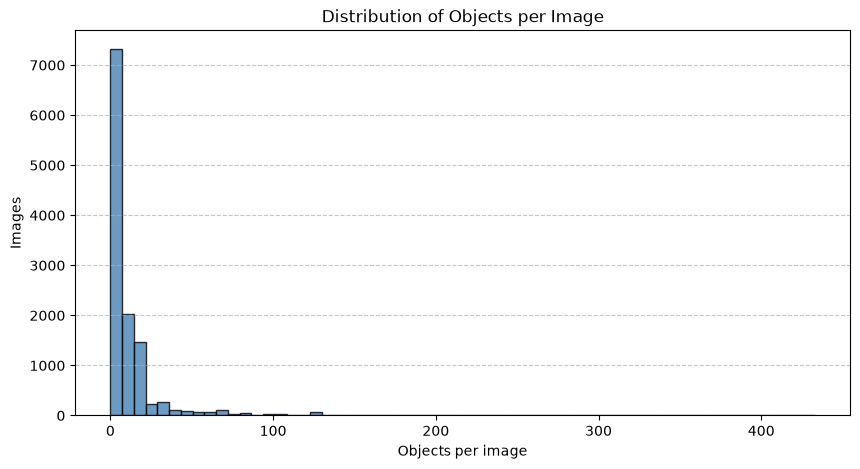

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(
    images_df["objects"],
    bins=60,
    edgecolor="black",
    color="steelblue",
    alpha=0.8,
)
plt.xlabel("Objects per image")
plt.ylabel("Images")
plt.title("Distribution of Objects per Image")
plt.grid(axis="y", linestyle="--", alpha=0.7) 
plt.show()

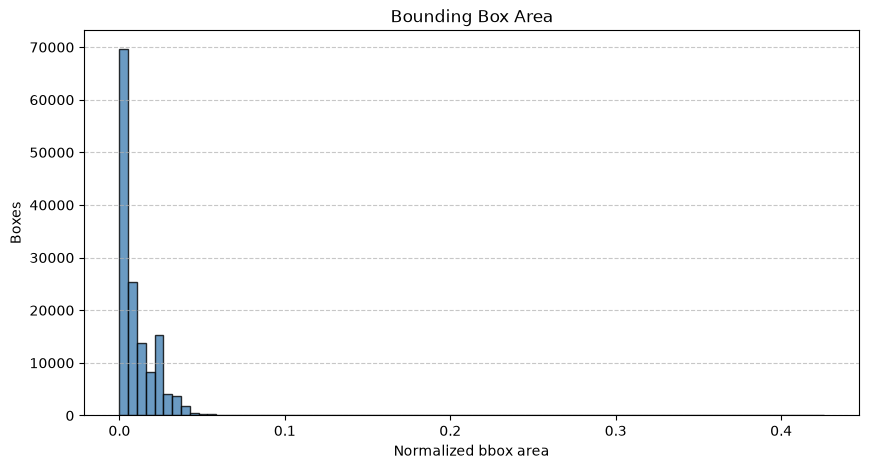

In [36]:
plt.figure(figsize=(10, 5))
plt.hist(
    ann_df["area"],
    bins=80,
    edgecolor="black",
    color="steelblue",
    alpha=0.8,
)
plt.xlabel("Normalized bbox area")
plt.ylabel("Boxes")
plt.title("Bounding Box Area")
plt.grid(axis="y", linestyle="--", alpha=0.7) 
plt.show()

### Visualize labels

In [39]:
def show_image(row):
    with Image.open(row.image_path) as im:
        image = ImageOps.exif_transpose(im).convert("RGB")
    boxes = ann_df[(ann_df["split"] == row.split) & (ann_df["stem"] == row.stem)]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(image)
    for box in boxes.itertuples(index=False):
        x = box.x1 * image.width
        y = box.y1 * image.height
        width = box.w * image.width
        height = box.h * image.height
        rect = patches.Rectangle(
            (x, y),
            width,
            height,
            linewidth=1,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)

    ax.set_title(f"{row.split} | {row.stem} | objects={row.objects}")
    ax.axis("off")
    plt.show()


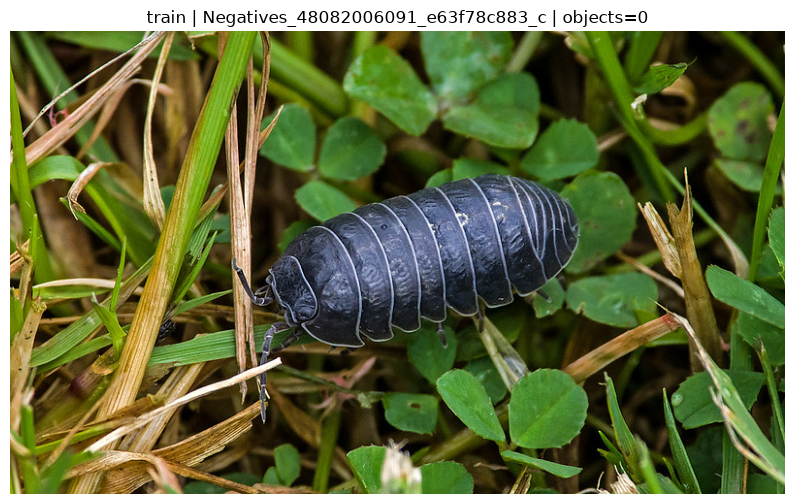

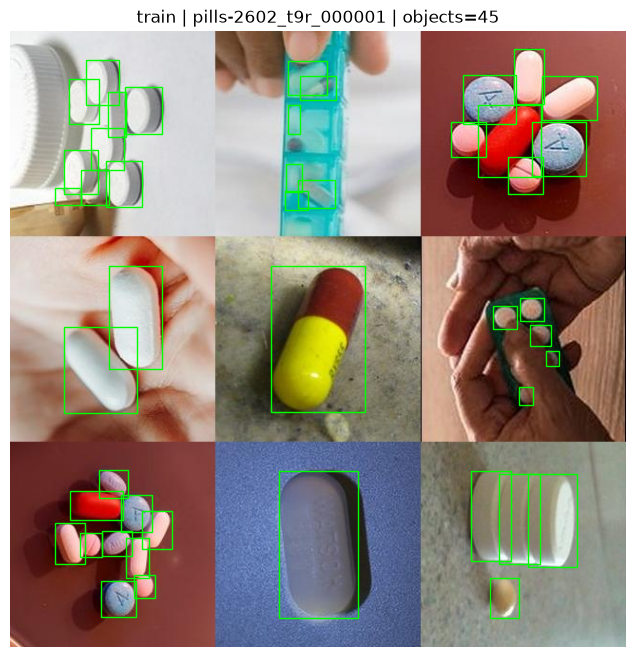

In [43]:
# ดูรูปแรกในตาราง
show_image(images_df.iloc[0])

# หรือสุ่มดู 1 รูป
sample_row = images_df.sample(1).iloc[0]
show_image(sample_row)

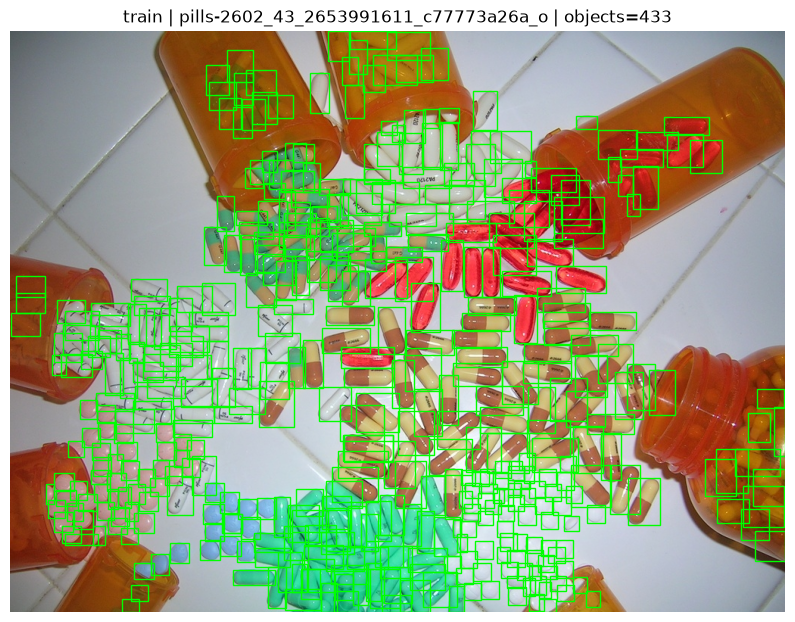

In [46]:
crowded = images_df.sort_values(
    "objects",
    ascending=False,
).iloc[0]

show_image(crowded)


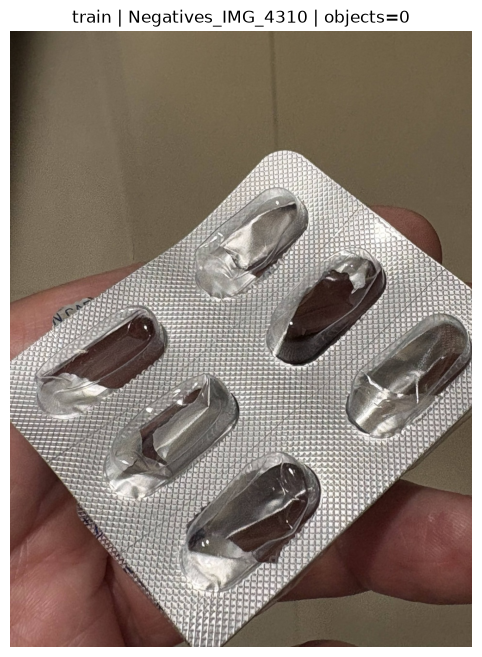

In [48]:
negative = (
    images_df[images_df["objects"] == 0]
    .sample(
        1,
        random_state=42,
    )
    .iloc[0]
)

show_image(negative)


### Duplicate / Leakage

In [49]:
def sha256_file(path, chunk_size=1024 * 1024,):
    digest = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(chunk_size),b"",):
            digest.update(chunk)
    return digest.hexdigest()

In [50]:
hash_df = images_df[
    [
        "split",
        "stem",
        "image_path",
    ]
].copy()

hash_df["sha256"] = hash_df["image_path"].map(sha256_file)


In [54]:
# ดึงภาพซ้ำกันออกมาทั้งหมด
# keep=False เก็บทุกแถวที่ซ้ำ
duplicates = hash_df[
    hash_df.duplicated(
        "sha256",
        keep=False,
    )
].copy()

# เอา splot ไม่ซ้ำออกมา
cross_split_hashes = duplicates.groupby("sha256")["split"].nunique()
# เอาเฉพาะค่า hash ที่พบมากกว่า 1 
cross_split_hashes = cross_split_hashes[cross_split_hashes > 1].index
# เอารูปที่ data leak ออกมา 
cross_split_duplicates = duplicates[duplicates["sha256"].isin(cross_split_hashes)]

display(cross_split_duplicates)


,split,stem,image_path,sha256
10444,train,Various_drugs-hand_44527-267,c:\Project\pill-object-detection\pill-dataset\...,c2af2a1b7ee97f8810f366107e95cdcdc7f6a60c0ec040...
10502,train,Various_medicine(62),c:\Project\pill-object-detection\pill-dataset\...,905579c0c9590fc9ebd91f79c0b783ed0db853a67352d9...
12056,val,Various_medicine(44),c:\Project\pill-object-detection\pill-dataset\...,c2af2a1b7ee97f8810f366107e95cdcdc7f6a60c0ec040...
12063,val,Various_medicine-pills-capsules-hand_20693-98,c:\Project\pill-object-detection\pill-dataset\...,905579c0c9590fc9ebd91f79c0b783ed0db853a67352d9...
